In [1]:
import os, sys
import numpy as np
module_path = os.path.abspath(os.path.join('..'))
sys.path.append(os.path.join(module_path, "KAN_variants"))
from ChebyKANLayer import ChebyKAN

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(os.path.join(module_path, "code"))
from myKANODE import KANODE

In [2]:
def pred_prey_deriv(X, t, alpha, beta, delta, gamma):
    x=X[0]
    y=X[1]
    dxdt = alpha*x-beta*x*y
    dydt = delta*x*y-gamma*y
    dXdt=[dxdt, dydt]
    return dXdt

# alpha, beta, delta, gamma
params = [1.5, 1, 2, 1]
X0 = [0.1, 1.5]

100%|██████████| 10000/10000 [10:19:58<00:00,  3.72s/it] 


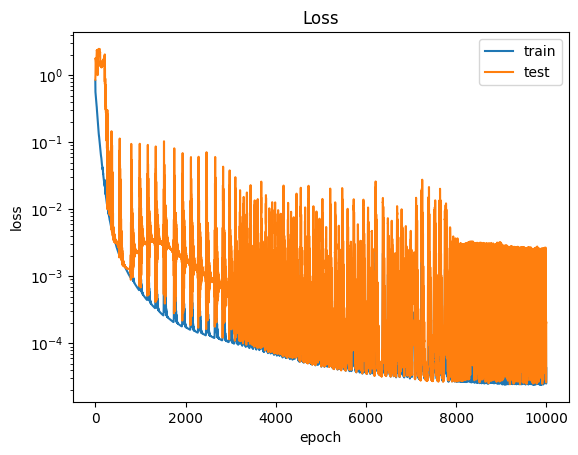

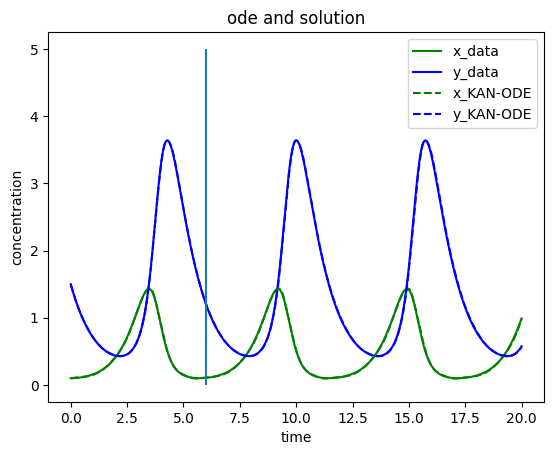

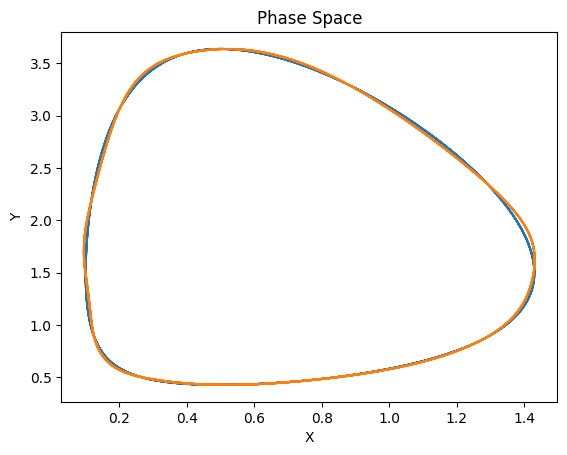

In [3]:
saveDirectory = os.path.join(module_path, "savedModels", "optimisedModel3")
model = ChebyKAN([2, 10, 2], 4)
kanODE = KANODE(model, pred_prey_deriv, X0, params, 20, 6, 0.01)
kanODE.train(-1, solverMethod="rk4", saveDirectory=saveDirectory, saveCooldown=200)
_, solution = kanODE.test()
kanODE.plotLoss("Loss")
kanODE.plotODE("ode and solution", solution[:, 0, :])
kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])

In [ ]:
kanODE.saveModel(saveDirectory, "finalIteration")

: 